In [1]:
import numpy as np
import pandas as pd

import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
from sklearn.decomposition import PCA

In [2]:
train = pd.read_csv(r"C:\Users\Administrator\Desktop\研\研一下\机器学习\报告\input\train.csv")
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print(train.shape)

(42000, 785)


In [4]:
target = train['label']
train = train.drop("label",axis=1)

In [5]:
# 手动实现PCA底层数学流程
# 数据标准化
from sklearn.preprocessing import StandardScaler
X = train.values
X_std = StandardScaler().fit_transform(X)

# 计算协方差矩阵
mean_vec = np.mean(X_std, axis=0)
cov_mat = np.cov(X_std.T)

# 特征值、特征向量分解
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

# 遍历所有特征维度，把特征值绝对值和对应一列特征向量绑定成元组
eig_pairs = [ (np.abs(eig_vals[i]),eig_vecs[:,i]) for i in range(len(eig_vals))]

# 特征值从小到大排序
eig_pairs.sort(key = lambda x: x[0], reverse= True)

# 计算单主成分方差解释率和累计方差解释率
tot = sum(eig_vals)
var_exp = [(i/tot)*100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

In [6]:
# 绘制PCA方差解释曲线，两条曲线画在同一张画布
# 1是累计方差曲线，x轴是784个主成分序号，y轴是累计方差解释率，曲线持续上升，直观展示保留多少主成分能覆盖全部数据信息
trace1 = go.Scatter(
    x=list(range(784)),
    y= cum_var_exp,
    mode='lines+markers',
    name="'Cumulative Explained Variance'",
    line=dict(
        shape='spline',
        color = 'goldenrod'
    )
)

# 2是单主成分方差曲线，曲线快速下降，前面的主成分方差贡献很高
trace2 = go.Scatter(
    x=list(range(784)),
    y= var_exp,
    mode='lines+markers',
    name="'Individual Explained Variance'",
    line=dict(
        shape='linear',
        color = 'red'
    )
)

# 创建画布，内嵌放大子图
fig = make_subplots(insets=[{'cell': (1,1), 'l': 0.7, 'b': 0.5}],
                          print_grid=True)

# 把两条曲线添加到画布
fig.add_trace(trace1, 1, 1)
fig.add_trace(trace2, 1, 1)

# 全局坐标轴与标题配置
fig.layout.title = 'Explained Variance plots'
fig.layout.xaxis = dict(range=[0, 80], title = 'Feature columns')
fig.layout.yaxis = dict(range=[0, 60], title = 'Explained Variance')
fig.show()

This is the format of your plot grid:
[ (1,1) x,y ]

With insets:
[ x2,y2 ] over [ (1,1) x,y ]



In [7]:
# 使用SKlearn的PCA，只保留前28个信息量最大的主成分
n_components = 28
pca = PCA(n_components=n_components).fit(train.values)

# 把每行784长度的主成分向量还原回像素图片矩阵
eigenvalues = pca.components_.reshape(n_components, 28, 28)

# 存储二维数组
eigenvalues = pca.components_

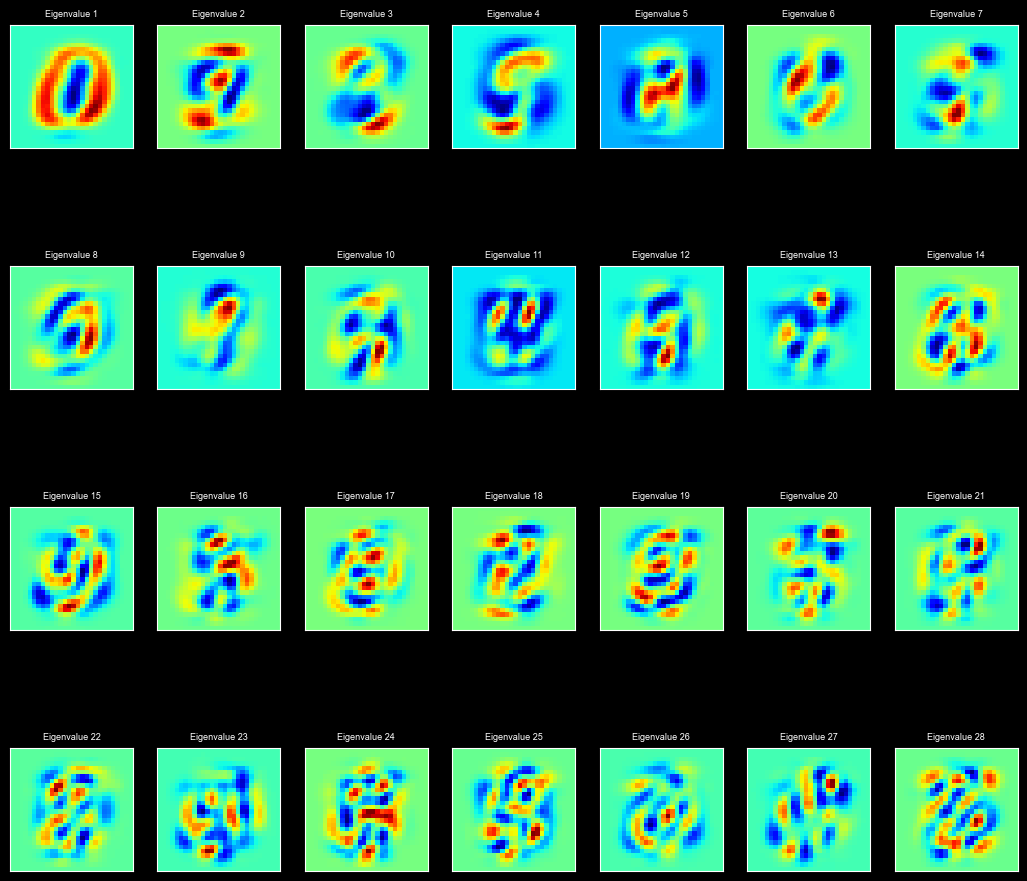

In [8]:
# 画出前28个PCA主成分图像，前几个主成分拥有全局粗轮廓，携带绝大部分信息
n_row = 4
n_col = 7

plt.figure(figsize=(13,12))
for i in list(range(n_row * n_col)):
    offset =0
    plt.subplot(n_row, n_col, i + 1)
    plt.imshow(eigenvalues[i].reshape(28,28), cmap='jet')
    title_text = 'Eigenvalue ' + str(i + 1)
    plt.title(title_text, size=6.5)
    plt.xticks(())
    plt.yticks(())
plt.show()

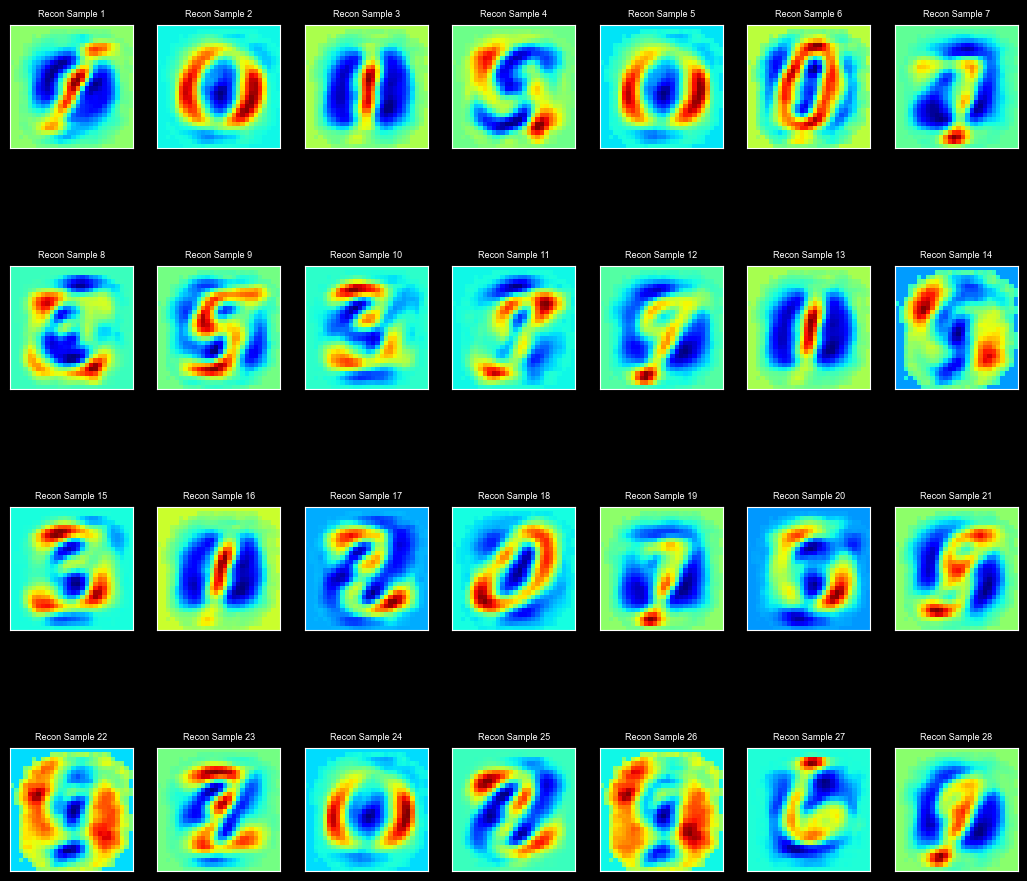

In [9]:
from sklearn.decomposition import KernelPCA
X = train.values
X = X[:3000]
X_std = StandardScaler().fit_transform(X)

kpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.0005, fit_inverse_transform=True)
X_kpca = kpca.fit_transform(X_std)

X_recon = kpca.inverse_transform(X_kpca)
n_row, n_col = 4,7
plt.figure(figsize=(13,12))
for i in range(n_row*n_col):
    plt.subplot(n_row, n_col, i+1)
    plt.imshow(X_recon[i].reshape(28,28), cmap='jet')
    plt.title(f'Recon Sample {i+1}', size=6.5)
    plt.xticks(())
    plt.yticks(())
plt.show()